In [20]:
# develope the som neural network
# realize all processes myself as code training
import numpy as np
import matplotlib.pyplot as plt

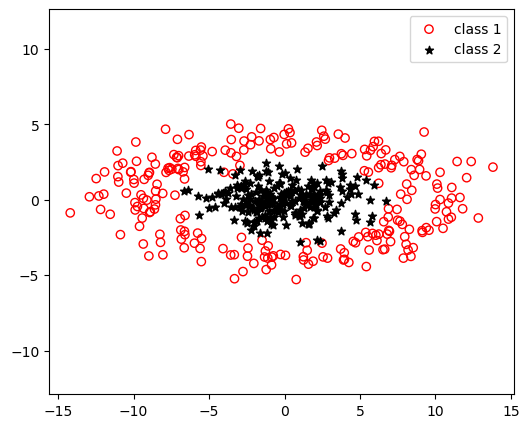

In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# ---------- class 2 : 中心椭球 ----------
n_inner = 250

inner = np.random.randn(n_inner,2)

ellipse_scale = np.array([[2.5,0],
                          [0,1]])

inner = inner @ ellipse_scale


# ---------- class 1 : 外部环 ----------
n_outer = 250

theta = np.random.uniform(0,2*np.pi,n_outer)

# 控制环的位置
r = np.random.normal(4,0.7,n_outer)

x = r*np.cos(theta)
y = r*np.sin(theta)

outer = np.column_stack((x,y))

outer = outer @ ellipse_scale


# ---------- 画图 ----------
plt.figure(figsize=(6,5))

plt.scatter(outer[:,0],outer[:,1],
            facecolors='none',edgecolors='red',
            label='class 1')

plt.scatter(inner[:,0],inner[:,1],
            marker='*',color='black',
            label='class 2')

plt.legend()
plt.axis("equal")

plt.show()

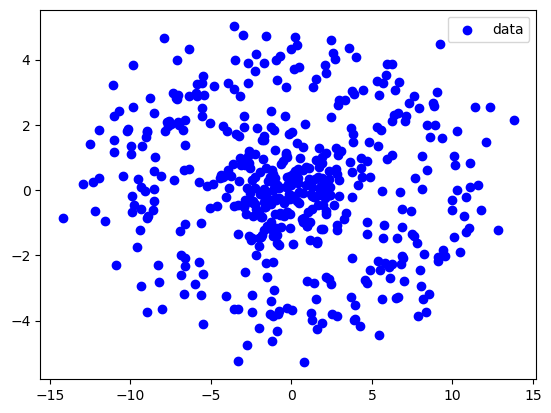

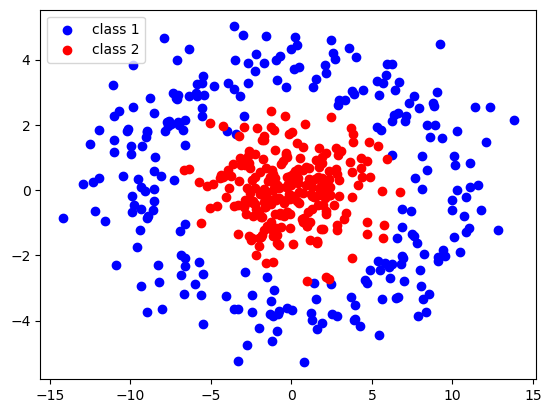

In [22]:
# fusion outer and inner data
data=np.vstack((outer,inner))
plt.scatter(data[:,0],data[:,1],c='blue',label='data')
plt.legend()
plt.show()
plt.scatter(outer[:,0],outer[:,1],c='blue',label='class 1')
plt.scatter(inner[:,0],inner[:,1],c='red',label='class 2')
plt.legend()
plt.show()
label=np.hstack((np.ones(n_outer),np.zeros(n_inner)))

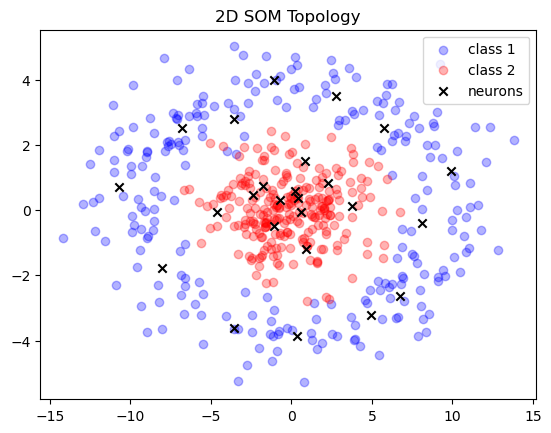

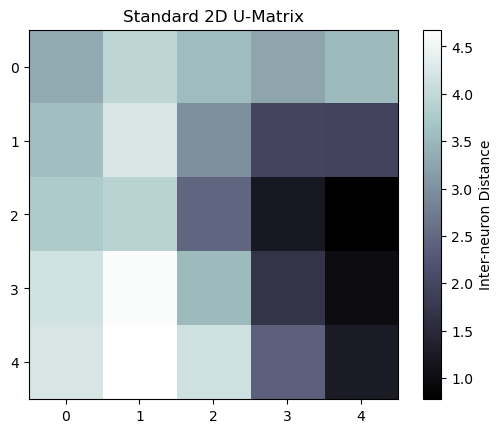

In [23]:
class SOMnn:
    # initialization
    def __init__(self,m,n,d):
        self.m=m
        self.n=n
        self.hidden_neuron=m*n
        self.feature_dim=d
        self.weight=np.random.rand(m,n,d)
    # competition
    def competition(self,x):
        distance=np.linalg.norm(self.weight-x,axis=2)
        winner_coords=np.unravel_index(np.argmin(distance),(self.m,self.n))
        return winner_coords
    # updating
    def update(self,x,winner_coords,learning_rate,sigma):
        w_row,w_col=winner_coords
        rows, cols = np.indices((self.m, self.n))
        dist_sq = (rows - w_row)**2 + (cols - w_col)**2
        h=np.exp(-dist_sq/(2*sigma**2))
        h=h[:,:,np.newaxis]
        self.weight+=learning_rate*h*(x-self.weight)

def som_loop(data):
    # include data
    # create 4 different gaussian distribution data

    # data=np.zeros((100,2))
    # data[:25,:]=np.random.randn(25,2)+np.array([0,0])
    # data[25:50,:]=np.random.randn(25,2)+np.array([0,3])
    # data[50:75,:]=np.random.randn(25,2)+np.array([3,0])
    # data[75:,:]=np.random.randn(25,2)+np.array([3,3]) 

    # begin building som nn
    ## 1. initialize the weight
    som=SOMnn(5,5,2)
    sigma0=1.0
    eta0=0.1
    # self-organizing
    sigma=sigma0
    eta=eta0
    itr=0
    while eta>0.01 and sigma>0.1:
        itr+=1
        ## 2. sampling
        x=data[np.random.randint(0,data.shape[0])]
        ## 3. competition
        winner_index=som.competition(x)
        ## 4. updating
        sigma=sigma0*(1-itr/1000)
        eta=eta0*(1-itr/1000)
        som.update(x,winner_index,eta,sigma)
    # convergence phase
    eta=0.01
    for epoch in range(500*data.shape[0]):
        x=data[np.random.randint(0,100)]
        winner_index=som.competition(x)
        som.update(x,winner_index,eta,0.1)
    # end
    return som.weight

# umatrix to evaluation
def umatrix(som_weight):
    m, n, d = som_weight.shape
    umat = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            # 找到当前神经元的邻居坐标
            neighbors = []
            if i > 0: neighbors.append(som_weight[i-1, j]) # 上
            if i < m-1: neighbors.append(som_weight[i+1, j]) # 下
            if j > 0: neighbors.append(som_weight[i, j-1]) # 左
            if j < n-1: neighbors.append(som_weight[i, j+1]) # 右
            
            # 计算到所有邻居的平均距离
            dist = [np.linalg.norm(som_weight[i, j] - nb) for nb in neighbors]
            umat[i, j] = np.mean(dist)
    return umat

def main():
    som_weight = som_loop(data)
    
    # 画出原始数据
    plt.scatter(outer[:,0], outer[:,1], c='blue', alpha=0.3, label='class 1')
    plt.scatter(inner[:,0], inner[:,1], c='red', alpha=0.3, label='class 2')
    
    # 画出神经元节点 (需要将 5x5x2 转为 25x2)
    flat_weight = som_weight.reshape(-1, 2)
    plt.scatter(flat_weight[:,0], flat_weight[:,1], c='black', marker='x', label='neurons')

    plt.legend()
    plt.title("2D SOM Topology")
    plt.show()

    # 画出真正的 U-Matrix
    u = umatrix(som_weight)
    plt.imshow(u, cmap='bone')
    plt.colorbar(label='Inter-neuron Distance')
    plt.title("Standard 2D U-Matrix")
    plt.show()



if __name__=='__main__':
    main()

    
    



In [28]:
import pandas as pd
# save data with sample and label with .csv
pd.DataFrame(data, columns=['x1','x2']).to_csv('dataset/unlinear_data.csv', index=False)
pd.DataFrame(label, columns=['label']).to_csv('dataset/unlinear_label.csv', index=False)
pd.DataFrame(outer, columns=['x1','x2']).to_csv('dataset/outer_data.csv', index=False)
pd.DataFrame(inner, columns=['x1','x2']).to_csv('dataset/inner_data.csv', index=False)